In [ ]:
import numpy as np
import pandas as pd
import time as tm
import matplotlib.pyplot as plt

In [10]:

a, b = 20.0, 10.0  # Dimensiones en mm
nx, ny = 41, 21    # Puntos de la malla en x e y

x = np.linspace(0, a, nx)
y = np.linspace(0, b, ny)
V_ini = np.zeros((ny, nx)) # Matriz de (filas=ny, columnas=nx)

def Laplace2D_FDM(V_ini, Niter=5000, tol=1e-4):
    '''
    Resuelve la ecuación de Laplace en 2D usando Diferencias Finitas.
    '''
    ny, nx = V_ini.shape
    V = V_ini.copy()
    x = np.linspace(0, a, nx)

    for iter_count in range(1, Niter + 1):
        V_old = V.copy()

        # Actualización de nodos internos
        for i in range(1, ny - 1):
            for j in range(1, nx - 1):
                V[i, j] = 0.25 * (V[i+1, j] + V[i-1, j] + V[i, j+1] + V[i, j-1])

        # Condiciones de Frontera
        V[0, :] = 0.0                                      # Inferior (y = 0)
        V[:, 0] = 0.0                                      # Izquierda (x = 0)
        V[:, nx - 1] = 0.0                                 # Derecha (x = a)
        V[ny - 1, :] = 100.0 * np.sin(3.0 * np.pi * x / a) # Superior (y = b)

        # Criterio de convergencia
        conv = np.max(np.abs(V - V_old))
        if conv <= tol:
            print(f"Convergencia alcanzada en la iteración {iter_count} (Residuo: {conv:.2e})")
            break

    return V

Convergencia alcanzada en la iteración 279 (Residuo: 9.98e-05)


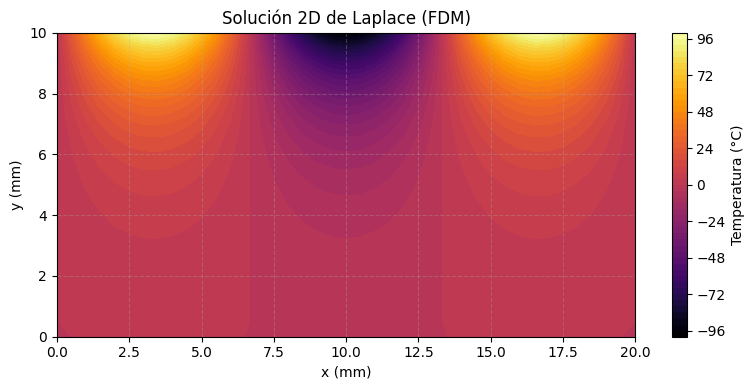

In [11]:
def grid(V_out, x, y):
    '''
    Genera las mallas X, Y y asigna Z para graficar.
    '''
    X, Y = np.meshgrid(x, y)
    Z = V_out.copy()  # El valor del campo Z es directamente la matriz V
    return X, Y, Z

# ==========================================
# 2. Ejecución y Graficación
# ==========================================
# Resolver
V_sol = Laplace2D_FDM(V_ini, Niter=5000)

# Obtener malla para gráfico
X, Y, Z = grid(V_sol, x, y)

# Graficar mapa de contorno
plt.figure(figsize=(8, 4))
grafico = plt.contourf(X, Y, Z, levels=50, cmap='inferno')
plt.colorbar(grafico, label='Temperatura (°C)')

plt.title('Solución 2D de Laplace (FDM)')
plt.xlabel('x (mm)')
plt.ylabel('y (mm)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()



#Problema 2

# Solución Analítica Estática (Ecuación de Laplace)

Al asumir estado estacionario ($\frac{\partial T}{\partial t} = 0$), la ecuación de difusión se reduce a la ecuación de Laplace:

$$ \frac{\partial^2 T}{\partial x^2} + \frac{\partial^2 T}{\partial y^2} = 0 $$

### Condiciones de Frontera:
1. $T(0, y) = 0$
2. $T(a, y) = 0$
3. $T(x, 0) = 0$
4. $T(x, b) = 100 \sin\left(\frac{3\pi x}{a}\right)$

### Paso 1: Separación de Variables
Proponemos $T(x,y) = X(x)Y(y)$:

$$ X''(x)Y(y) + X(x)Y''(y) = 0 \implies \frac{X''(x)}{X(x)} = -\frac{Y''(y)}{Y(y)} = -\lambda^2 $$

### Paso 2: Solución para $X(x)$
$$ X''(x) + \lambda^2 X(x) = 0 \implies X(x) = A \cos(\lambda x) + B \sin(\lambda x) $$

* Con $X(0) = 0 \implies A = 0$
* Con $X(a) = 0 \implies \sin(\lambda a) = 0 \implies \lambda_n = \frac{n\pi}{a} \quad (n = 1, 2, 3, \dots)$

$$ X_n(x) = \sin\left(\frac{n\pi x}{a}\right) $$

### Paso 3: Solución para $Y(y)$
$$ Y''(y) - \left(\frac{n\pi}{a}\right)^2 Y(y) = 0 \implies Y(y) = C \cosh\left(\frac{n\pi y}{a}\right) + D \sinh\left(\frac{n\pi y}{a}\right) $$

* Con $Y(0) = 0 \implies C = 0$

$$ Y_n(y) = \sinh\left(\frac{n\pi y}{a}\right) $$

### Paso 4: Superposición y Frontera Superior
$$ T(x,y) = \sum_{n=1}^{\infty} E_n \sin\left(\frac{n\pi x}{a}\right) \sinh\left(\frac{n\pi y}{a}\right) $$

Evaluando en $y = b$:
$$ T(x,b) = \sum_{n=1}^{\infty} E_n \sinh\left(\frac{n\pi b}{a}\right) \sin\left(\frac{n\pi x}{a}\right) = 100 \sin\left(\frac{3\pi x}{a}\right) $$

Observamos que la funcion seno debe cumple que para $n = 3$:
$$ E_3 = \frac{100}{\sinh\left(\frac{3\pi b}{a}\right)} $$

### Solución Exacta
$$ T(x,y) = 100 \frac{\sinh\left(\frac{3\pi y}{a}\right)}{\sinh\left(\frac{3\pi b}{a}\right)} \sin\left(\frac{3\pi x}{a}\right) $$

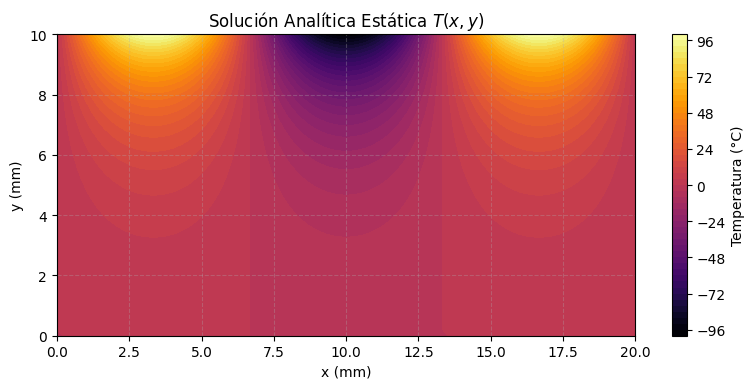

In [7]:
# Parámetros geométricos (en mm)
a = 20.0
b = 10.0

# Creación de la malla espacial
nx, ny = 100, 50
x = np.linspace(0, a, nx)
y = np.linspace(0, b, ny)
X, Y = np.meshgrid(x, y)

# Evaluación de la función analítica en la malla
T_estatico = 100 * (np.sinh(3 * np.pi * Y / a) / np.sinh(3 * np.pi * b / a)) * np.sin(3 * np.pi * X / a)

# Visualización
plt.figure(figsize=(8, 4))
mapa = plt.contourf(X, Y, T_estatico, levels=50, cmap='inferno')
plt.colorbar(mapa, label='Temperatura (°C)')

plt.title('Solución Analítica Estática $T(x,y)$')
plt.xlabel('x (mm)')
plt.ylabel('y (mm)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()



#Problema 3

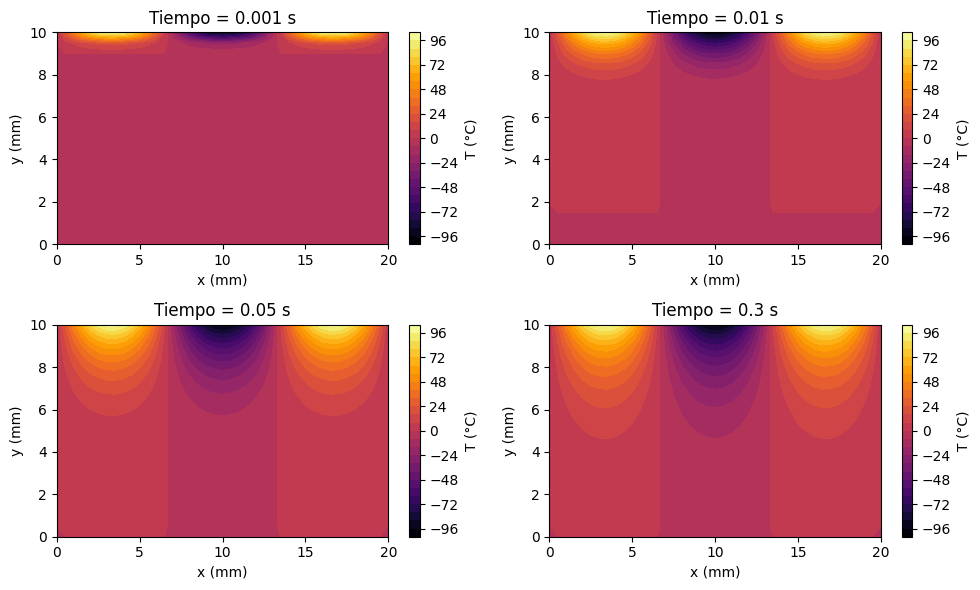

In [12]:

a, b = 20.0, 10.0      # Dimensiones de la placa (mm)
D = 84.0               # Difusividad térmica (mm^2/s)

dx, dy = 0.5, 0.5      # Tamaño de la grilla (mm)
nx = int(a / dx) + 1
ny = int(b / dy) + 1

x = np.linspace(0, a, nx)
y = np.linspace(0, b, ny)
X, Y = np.meshgrid(x, y)

# Paso de tiempo según estabilidad CFL
dt = 0.8 * (1.0 / (2 * D * (1/dx**2 + 1/dy**2)))

rx = D * dt / (dx**2)
ry = D * dt / (dy**2)

def simular_hasta(t_final):
    # Crear placa a 0°C
    T = np.zeros((ny, nx))

    # Condición de frontera superior: y = b
    T[-1, :] = 100 * np.sin(3 * np.pi * x / a)

    # Calcular cuántas iteraciones se necesitan para llegar al tiempo deseado
    pasos = int(t_final / dt)

    # Bucle temporal
    for _ in range(pasos):
        T_nuevo = T.copy()

        # Fórmula de diferencias finitas en nodos internos
        T_nuevo[1:-1, 1:-1] = (
            T[1:-1, 1:-1] +
            rx * (T[1:-1, 2:] - 2*T[1:-1, 1:-1] + T[1:-1, :-2]) +
            ry * (T[2:, 1:-1] - 2*T[1:-1, 1:-1] + T[:-2, 1:-1])
        )
        T = T_nuevo

    return T

tiempos = [0.001, 0.01, 0.05, 0.3]

plt.figure(figsize=(10, 6))

for i, t in enumerate(tiempos):
    # 1. Calcular la temperatura en el tiempo t
    T_res = simular_hasta(t)

    # 2. Graficar en la posición i+1 (1, 2, 3, 4)
    plt.subplot(2, 2, i + 1)
    plt.contourf(X, Y, T_res, levels=30, cmap='inferno')
    plt.colorbar(label='T (°C)')
    plt.title(f'Tiempo = {t} s')
    plt.xlabel('x (mm)')
    plt.ylabel('y (mm)')

plt.tight_layout()
plt.show()